#  Automated Multi-Format Sales Report Pipeline

**Extract → Transform → Generate → Deliver**

This notebook implements a production-ready automated report pipeline that:
- Loads raw sales data for 5 products across 6 months
- Calculates revenue and aggregates product/monthly summaries
- Generates reports in **Excel**, **HTML**, and **PDF** formats
- Optionally delivers the report via **email** (SMTP)

---
| Stage | Description |
|-------|-------------|
| **Extract** | Load raw sales records from a source system |
| **Transform** | Calculate Revenue, aggregate by product and month |
| **Generate** | Produce styled Excel, HTML, and PDF reports |
| **Deliver** | Email the chosen report via SMTP |

## 0. Install Dependencies

Run this cell once to install all required packages.

In [ ]:
# Uncomment and run if packages are not yet installed
# !pip install openpyxl jinja2 fpdf2 matplotlib pandas

## 1. Imports & Configuration

In [1]:
import os
import smtplib
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

from jinja2 import Template
from fpdf import FPDF

# ── Configuration ──────────────────────────────────────────
REPORTS_DIR = "reports"
DATE_STAMP  = datetime.now().strftime("%Y-%m-%d")

os.makedirs(REPORTS_DIR, exist_ok=True)
print(f"Reports will be saved to: ./{REPORTS_DIR}/")
print(f"Date stamp: {DATE_STAMP}")

Reports will be saved to: ./reports/
Date stamp: 2026-03-11


---
## Step 1 — EXTRACT

The Extract stage loads raw sales records from a source system. 

In this implementation the data is an in-memory fixture, but you can swap `extract_data()` to read from a **SQL database**, **CSV file**, or **REST API** without changing any downstream logic.

**Fields:** `Month`, `Product`, `Units_Sold`, `Unit_Price`, `Region`

In [2]:
def extract_data() -> pd.DataFrame:
    """Simulate loading raw sales data from a source system."""
    raw = [
        # Month,        Product,              Units,  Price,    Region
        ("Jan 2024", "Laptop Pro 15",          120,  1299.99, "North"),
        ("Jan 2024", "Wireless Headphones",    340,   149.99, "South"),
        ("Jan 2024", "Smart Watch Ultra",      210,   399.99, "East"),
        ("Jan 2024", "Tablet Air 10",          180,   549.99, "West"),
        ("Jan 2024", "Bluetooth Speaker",      290,    89.99, "North"),
        ("Feb 2024", "Laptop Pro 15",          145,  1299.99, "South"),
        ("Feb 2024", "Wireless Headphones",    390,   149.99, "East"),
        ("Feb 2024", "Smart Watch Ultra",      255,   399.99, "West"),
        ("Feb 2024", "Tablet Air 10",          200,   549.99, "North"),
        ("Feb 2024", "Bluetooth Speaker",      320,    89.99, "South"),
        ("Mar 2024", "Laptop Pro 15",          160,  1299.99, "East"),
        ("Mar 2024", "Wireless Headphones",    410,   149.99, "West"),
        ("Mar 2024", "Smart Watch Ultra",      280,   399.99, "North"),
        ("Mar 2024", "Tablet Air 10",          225,   549.99, "South"),
        ("Mar 2024", "Bluetooth Speaker",      350,    89.99, "East"),
        ("Apr 2024", "Laptop Pro 15",          175,  1299.99, "West"),
        ("Apr 2024", "Wireless Headphones",    445,   149.99, "North"),
        ("Apr 2024", "Smart Watch Ultra",      300,   399.99, "South"),
        ("Apr 2024", "Tablet Air 10",          240,   549.99, "East"),
        ("Apr 2024", "Bluetooth Speaker",      375,    89.99, "West"),
        ("May 2024", "Laptop Pro 15",          190,  1299.99, "North"),
        ("May 2024", "Wireless Headphones",    480,   149.99, "South"),
        ("May 2024", "Smart Watch Ultra",      315,   399.99, "East"),
        ("May 2024", "Tablet Air 10",          260,   549.99, "West"),
        ("May 2024", "Bluetooth Speaker",      400,    89.99, "North"),
        ("Jun 2024", "Laptop Pro 15",          205,  1299.99, "South"),
        ("Jun 2024", "Wireless Headphones",    510,   149.99, "East"),
        ("Jun 2024", "Smart Watch Ultra",      330,   399.99, "West"),
        ("Jun 2024", "Tablet Air 10",          275,   549.99, "North"),
        ("Jun 2024", "Bluetooth Speaker",      420,    89.99, "South"),
    ]
    df = pd.DataFrame(raw, columns=["Month", "Product", "Units_Sold", "Unit_Price", "Region"])
    print(f"[EXTRACT] Loaded {len(df)} records across {df['Month'].nunique()} months.")
    return df


# Run extraction
raw_df = extract_data()
raw_df.head(10)

[EXTRACT] Loaded 30 records across 6 months.


,Month,Product,Units_Sold,Unit_Price,Region
0,Jan 2024,Laptop Pro 15,120,1299.99,North
1,Jan 2024,Wireless Headphones,340,149.99,South
2,Jan 2024,Smart Watch Ultra,210,399.99,East
3,Jan 2024,Tablet Air 10,180,549.99,West
4,Jan 2024,Bluetooth Speaker,290,89.99,North
5,Feb 2024,Laptop Pro 15,145,1299.99,South
6,Feb 2024,Wireless Headphones,390,149.99,East
7,Feb 2024,Smart Watch Ultra,255,399.99,West
8,Feb 2024,Tablet Air 10,200,549.99,North
9,Feb 2024,Bluetooth Speaker,320,89.99,South


---
## Step 2 — TRANSFORM

The Transform stage is the **business logic layer**. It computes all derived metrics once, and every report format downstream reads from these same DataFrames — guaranteeing consistent figures across Excel, HTML, and PDF.

**Calculations:**
- `Revenue = Units_Sold × Unit_Price`
- Product summary: Total Units, Total Revenue, Avg Price, Revenue Share %
- Monthly totals (calendar order preserved)

In [3]:
def transform_data(df: pd.DataFrame):
    """Calculate Revenue, build product summary and monthly totals."""
    df = df.copy()

    # Revenue calculation
    df["Revenue"] = df["Units_Sold"] * df["Unit_Price"]

    # Product-level summary
    summary = (
        df.groupby("Product")
          .agg(
              Total_Units=("Units_Sold", "sum"),
              Total_Revenue=("Revenue", "sum"),
              Avg_Price=("Unit_Price", "mean"),
          )
          .reset_index()
          .sort_values("Total_Revenue", ascending=False)
    )
    total_rev = summary["Total_Revenue"].sum()
    summary["Revenue_Share_Pct"] = (summary["Total_Revenue"] / total_rev * 100).round(2)

    # Monthly totals — preserve calendar order
    month_order = df["Month"].unique().tolist()
    monthly = (
        df.groupby("Month")["Revenue"]
          .sum()
          .reindex(month_order)
          .reset_index()
          .rename(columns={"Revenue": "Monthly_Revenue"})
    )

    print(f"[TRANSFORM] Total revenue: ${total_rev:,.2f}")
    print(f"[TRANSFORM] Products: {summary['Product'].tolist()}")
    return df, summary, monthly


# Run transform
df, summary, monthly = transform_data(raw_df)

print("\n--- Product Summary ---")
display(summary.style.format({
    "Total_Revenue": "${:,.2f}",
    "Avg_Price": "${:,.2f}",
    "Revenue_Share_Pct": "{:.2f}%"
}))

print("\n--- Monthly Totals ---")
display(monthly.style.format({"Monthly_Revenue": "${:,.2f}"}))

[TRANSFORM] Total revenue: $3,308,612.05
[TRANSFORM] Products: ['Laptop Pro 15', 'Tablet Air 10', 'Smart Watch Ultra', 'Wireless Headphones', 'Bluetooth Speaker']

--- Product Summary ---


,Product,Total_Units,Total_Revenue,Avg_Price,Revenue_Share_Pct
1,Laptop Pro 15,995,"$1,293,490.05","$1,299.99",39.09%
3,Tablet Air 10,1380,"$758,986.20",$549.99,22.94%
2,Smart Watch Ultra,1690,"$675,983.10",$399.99,20.43%
4,Wireless Headphones,2575,"$386,224.25",$149.99,11.67%
0,Bluetooth Speaker,2155,"$193,928.45",$89.99,5.86%



--- Monthly Totals ---


,Month,Monthly_Revenue
0,Jan 2024,"$416,088.60"
1,Feb 2024,"$487,786.90"
2,Mar 2024,"$536,735.75"
3,Apr 2024,"$579,984.65"
4,May 2024,"$623,983.55"
5,Jun 2024,"$664,032.60"


---
## Step 3A — GENERATE Excel

Produces a styled, multi-sheet `.xlsx` workbook using **openpyxl** with:
- **Sheet 1**: Raw Data with formatted columns and alternating row colours
- **Sheet 2**: Product Summary with live `SUM`/`AVERAGE` Excel formulas
- **Sheet 3**: Monthly Revenue with a `SUM` formula total row

In [4]:
def generate_excel(df: pd.DataFrame, summary: pd.DataFrame, monthly: pd.DataFrame) -> str:
    """Create a styled, multi-sheet Excel workbook."""
    path = os.path.join(REPORTS_DIR, f"sales_report_{DATE_STAMP}.xlsx")
    wb = Workbook()

    # Colour palette
    NAVY, LIGHT, ALT, WHITE, GOLD = "1F3864", "D9E1F2", "EEF2FA", "FFFFFF", "FFD966"

    header_font = Font(name="Arial", bold=True, color=WHITE, size=11)
    cell_font   = Font(name="Arial", size=10)
    navy_fill   = PatternFill("solid", fgColor=NAVY)
    center      = Alignment(horizontal="center", vertical="center")
    thin        = Side(style="thin", color="CCCCCC")
    border      = Border(left=thin, right=thin, top=thin, bottom=thin)

    # ── Sheet 1: Raw Data ──────────────────────────────────────────────
    ws = wb.active
    ws.title = "Raw Data"
    ws.append(["", ""])
    ws.merge_cells("A1:F1")
    ws["A1"] = "Sales Raw Data - 2024"
    ws["A1"].fill = PatternFill("solid", fgColor=NAVY)
    ws["A1"].font = Font(name="Arial", bold=True, size=14, color=WHITE)
    ws["A1"].alignment = center
    ws.row_dimensions[1].height = 30

    headers = ["Month", "Product", "Units Sold", "Unit Price ($)", "Region", "Revenue ($)"]
    ws.append(headers)
    for col, h in enumerate(headers, 1):
        c = ws.cell(row=2, column=col)
        c.font = header_font; c.fill = navy_fill; c.alignment = center; c.border = border

    for i, row in enumerate(df.itertuples(index=False), start=3):
        fill = PatternFill("solid", fgColor=ALT) if i % 2 == 0 else PatternFill("solid", fgColor=WHITE)
        ws.append([row.Month, row.Product, row.Units_Sold, row.Unit_Price, row.Region, row.Revenue])
        for col in range(1, 7):
            c = ws.cell(row=i, column=col)
            c.font = cell_font; c.fill = fill; c.border = border; c.alignment = center
            if col in (4, 6): c.number_format = '$#,##0.00'
            elif col == 3:    c.number_format = '#,##0'

    for col, width in zip("ABCDEF", [12, 24, 12, 14, 10, 14]):
        ws.column_dimensions[col].width = width
    ws.freeze_panes = "A3"

    # ── Sheet 2: Product Summary ───────────────────────────────────────
    ws2 = wb.create_sheet("Product Summary")
    ws2.append([""])
    ws2.merge_cells("A1:E1")
    ws2["A1"] = "Product Performance Summary"
    ws2["A1"].font = Font(name="Arial", bold=True, size=14, color=WHITE)
    ws2["A1"].fill = navy_fill; ws2["A1"].alignment = center
    ws2.row_dimensions[1].height = 30

    s_headers = ["Product", "Total Units Sold", "Total Revenue ($)", "Avg Unit Price ($)", "Revenue Share (%)"]
    ws2.append(s_headers)
    for col, h in enumerate(s_headers, 1):
        c = ws2.cell(row=2, column=col)
        c.font = header_font; c.fill = navy_fill; c.alignment = center; c.border = border

    for i, row in enumerate(summary.itertuples(index=False), start=3):
        fill = PatternFill("solid", fgColor=ALT) if i % 2 == 0 else PatternFill("solid", fgColor=WHITE)
        ws2.append([row.Product, row.Total_Units, row.Total_Revenue, row.Avg_Price, row.Revenue_Share_Pct])
        for col in range(1, 6):
            c = ws2.cell(row=i, column=col)
            c.font = cell_font; c.fill = fill; c.border = border; c.alignment = center
            if col in (3, 4): c.number_format = '$#,##0.00'
            elif col == 2:    c.number_format = '#,##0'
            elif col == 5:    c.number_format = '0.00"%"'

    last = 3 + len(summary)
    ws2.append(["TOTAL", f"=SUM(B3:B{last-1})", f"=SUM(C3:C{last-1})",
                f"=AVERAGE(D3:D{last-1})", "100.00"])
    for col in range(1, 6):
        c = ws2.cell(row=last, column=col)
        c.font = Font(name="Arial", bold=True, size=10)
        c.fill = PatternFill("solid", fgColor=GOLD)
        c.border = border; c.alignment = center
        if col in (3, 4): c.number_format = '$#,##0.00'
        elif col == 2:    c.number_format = '#,##0'

    for col, width in zip("ABCDE", [24, 16, 18, 18, 16]):
        ws2.column_dimensions[col].width = width

    # ── Sheet 3: Monthly Revenue ───────────────────────────────────────
    ws3 = wb.create_sheet("Monthly Revenue")
    ws3.merge_cells("A1:B1")
    ws3["A1"] = "Monthly Revenue Summary"
    ws3["A1"].font = Font(name="Arial", bold=True, size=14, color=WHITE)
    ws3["A1"].fill = navy_fill; ws3["A1"].alignment = center
    ws3.row_dimensions[1].height = 30

    ws3.append(["Month", "Revenue ($)"])
    for col in range(1, 3):
        c = ws3.cell(row=2, column=col)
        c.font = header_font; c.fill = navy_fill; c.alignment = center; c.border = border

    for i, row in enumerate(monthly.itertuples(index=False), start=3):
        fill = PatternFill("solid", fgColor=ALT) if i % 2 == 0 else PatternFill("solid", fgColor=WHITE)
        ws3.append([row.Month, row.Monthly_Revenue])
        for col in range(1, 3):
            c = ws3.cell(row=i, column=col)
            c.font = cell_font; c.fill = fill; c.border = border; c.alignment = center
            if col == 2: c.number_format = '$#,##0.00'

    last3 = 3 + len(monthly)
    ws3.append(["TOTAL", f"=SUM(B3:B{last3-1})"])
    for col in range(1, 3):
        c = ws3.cell(row=last3, column=col)
        c.font = Font(name="Arial", bold=True, size=10)
        c.fill = PatternFill("solid", fgColor=GOLD)
        c.border = border; c.alignment = center
        if col == 2: c.number_format = '$#,##0.00'

    for col, width in zip("AB", [14, 18]):
        ws3.column_dimensions[col].width = width

    wb.save(path)
    print(f"[GENERATE] Excel saved -> {path}")
    return path


excel_path = generate_excel(df, summary, monthly)

[GENERATE] Excel saved -> reports\sales_report_2026-03-11.xlsx


---
## Step 3B — GENERATE HTML

Uses a **Jinja2 template** to render a responsive HTML report containing:
- KPI summary cards (Total Revenue, Units Sold, Products, Months)
- Product Performance table with Revenue Share badges
- Monthly Revenue breakdown with percentage of total column

In [5]:
HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Sales Report {{ date }}</title>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { font-family: 'Segoe UI', Arial, sans-serif; background: #f0f4f8; color: #2d3748; }
  .wrapper { max-width: 1100px; margin: 40px auto; padding: 0 20px; }
  .header { background: linear-gradient(135deg, #1a365d 0%, #2b6cb0 100%);
            color: white; border-radius: 12px 12px 0 0; padding: 32px 40px; }
  .header h1 { font-size: 28px; letter-spacing: 0.5px; }
  .header p  { margin-top: 6px; opacity: 0.85; font-size: 14px; }
  .kpi-row { display: flex; gap: 16px; background: white;
             padding: 24px 40px; border-bottom: 1px solid #e2e8f0; }
  .kpi { flex: 1; text-align: center; }
  .kpi .val { font-size: 26px; font-weight: 700; color: #2b6cb0; }
  .kpi .lbl { font-size: 12px; color: #718096; text-transform: uppercase;
              letter-spacing: 0.8px; margin-top: 4px; }
  .section { background: white; padding: 32px 40px; margin-top: 2px; }
  .section h2 { font-size: 18px; color: #1a365d; border-left: 4px solid #2b6cb0;
                padding-left: 12px; margin-bottom: 20px; }
  table { width: 100%; border-collapse: collapse; font-size: 13.5px; }
  thead tr { background: #1a365d; color: white; }
  thead th { padding: 12px 14px; text-align: center; font-weight: 600; }
  tbody tr:nth-child(even) { background: #ebf4ff; }
  tbody tr:hover { background: #bee3f8; transition: background 0.15s; }
  tbody td { padding: 10px 14px; text-align: center; border-bottom: 1px solid #e2e8f0; }
  .product-name { text-align: left !important; font-weight: 500; }
  tfoot td { background: #fef3c7; font-weight: 700; padding: 11px 14px;
             border-top: 2px solid #f6ad55; text-align: center; }
  .badge { display: inline-block; background: #ebf8ff; color: #2b6cb0;
           border: 1px solid #bee3f8; border-radius: 12px; padding: 2px 10px; font-size: 12px; }
  .footer { background: white; border-radius: 0 0 12px 12px; padding: 20px 40px;
            text-align: center; color: #a0aec0; font-size: 12px;
            border-top: 1px solid #e2e8f0; margin-top: 2px; }
</style>
</head>
<body>
<div class="wrapper">
  <div class="header">
    <h1>&#128202; Sales Performance Report</h1>
    <p>Generated on {{ date }} &nbsp;|&nbsp; Reporting Period: Jan - Jun 2024 &nbsp;|&nbsp; All Regions</p>
  </div>
  <div class="kpi-row">
    <div class="kpi"><div class="val">${{ "%.0f"|format(total_revenue/1000) }}K</div><div class="lbl">Total Revenue</div></div>
    <div class="kpi"><div class="val">{{ total_units|int }}</div><div class="lbl">Units Sold</div></div>
    <div class="kpi"><div class="val">{{ num_products }}</div><div class="lbl">Products</div></div>
    <div class="kpi"><div class="val">{{ num_months }}</div><div class="lbl">Months Tracked</div></div>
  </div>
  <div class="section">
    <h2>Product Performance Summary</h2>
    <table>
      <thead><tr>
        <th style="text-align:left">Product</th>
        <th>Total Units Sold</th><th>Total Revenue</th>
        <th>Avg Unit Price</th><th>Revenue Share</th>
      </tr></thead>
      <tbody>
        {% for row in summary %}
        <tr>
          <td class="product-name">{{ row.Product }}</td>
          <td>{{ "{:,.0f}".format(row.Total_Units) }}</td>
          <td>${{ "{:,.2f}".format(row.Total_Revenue) }}</td>
          <td>${{ "{:,.2f}".format(row.Avg_Price) }}</td>
          <td><span class="badge">{{ "%.1f"|format(row.Revenue_Share_Pct) }}%</span></td>
        </tr>
        {% endfor %}
      </tbody>
      <tfoot><tr>
        <td>TOTAL</td>
        <td>{{ "{:,.0f}".format(total_units) }}</td>
        <td>${{ "{:,.2f}".format(total_revenue) }}</td>
        <td>-</td><td>100.0%</td>
      </tr></tfoot>
    </table>
  </div>
  <div class="section">
    <h2>Monthly Revenue Breakdown</h2>
    <table>
      <thead><tr><th>Month</th><th>Revenue</th><th>% of Total</th></tr></thead>
      <tbody>
        {% for row in monthly %}
        <tr>
          <td>{{ row.Month }}</td>
          <td>${{ "{:,.2f}".format(row.Monthly_Revenue) }}</td>
          <td>{{ "%.1f"|format(row.Monthly_Revenue / total_revenue * 100) }}%</td>
        </tr>
        {% endfor %}
      </tbody>
      <tfoot><tr>
        <td>TOTAL</td>
        <td>${{ "{:,.2f}".format(total_revenue) }}</td>
        <td>100.0%</td>
      </tr></tfoot>
    </table>
  </div>
  <div class="footer">Auto-generated by Sales Report Pipeline &nbsp;·&nbsp; {{ date }} &nbsp;·&nbsp; Confidential</div>
</div>
</body>
</html>"""


def generate_html(summary: pd.DataFrame, monthly: pd.DataFrame) -> str:
    path = os.path.join(REPORTS_DIR, f"sales_report_{DATE_STAMP}.html")
    tmpl = Template(HTML_TEMPLATE)
    html = tmpl.render(
        date=datetime.now().strftime("%B %d, %Y"),
        summary=summary.to_dict(orient="records"),
        monthly=monthly.to_dict(orient="records"),
        total_revenue=summary["Total_Revenue"].sum(),
        total_units=summary["Total_Units"].sum(),
        num_products=len(summary),
        num_months=len(monthly),
    )
    with open(path, "w") as f:
        f.write(html)
    print(f"[GENERATE] HTML saved  -> {path}")
    return path


html_path = generate_html(summary, monthly)

[GENERATE] HTML saved  -> reports\sales_report_2026-03-11.html


---
## Step 3C — GENERATE PDF

### 3C-i. Bar Chart Helper

Renders a monthly revenue bar chart using **matplotlib** and saves it as a temporary PNG for embedding in the PDF.

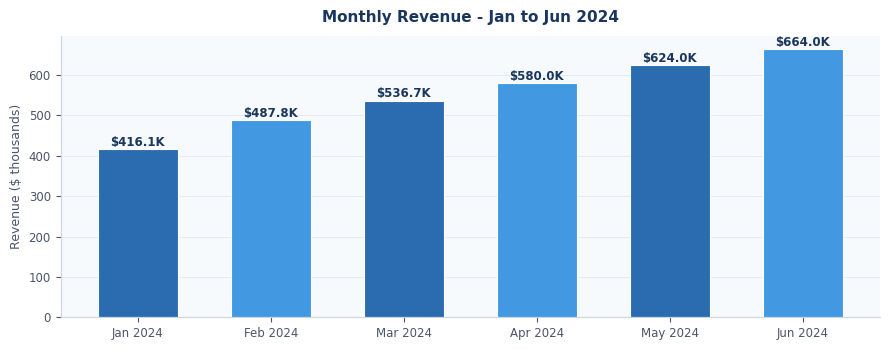

Chart preview rendered above.


In [6]:
def _make_bar_chart(monthly: pd.DataFrame, save_path: str) -> str:
    """Render monthly revenue bar chart; returns the saved file path."""
    fig, ax = plt.subplots(figsize=(9, 3.6))
    colours = ["#2b6cb0" if i % 2 == 0 else "#4299e1" for i in range(len(monthly))]
    bars = ax.bar(
        monthly["Month"], monthly["Monthly_Revenue"] / 1000,
        color=colours, edgecolor="white", linewidth=0.8, width=0.6
    )
    for bar, val in zip(bars, monthly["Monthly_Revenue"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"${val/1000:.1f}K", ha="center", va="bottom",
            fontsize=8.5, fontweight="bold", color="#1a365d"
        )
    ax.set_facecolor("#f7fafc")
    fig.patch.set_facecolor("#ffffff")
    ax.set_ylabel("Revenue ($ thousands)", fontsize=9, color="#4a5568")
    ax.set_title("Monthly Revenue - Jan to Jun 2024", fontsize=11,
                 fontweight="bold", color="#1a365d", pad=10)
    ax.tick_params(axis="x", labelsize=8.5, colors="#4a5568")
    ax.tick_params(axis="y", labelsize=8.5, colors="#4a5568")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#cbd5e0")
    ax.yaxis.grid(True, color="#e2e8f0", linewidth=0.6)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()   # Display inline in the notebook
    plt.close()
    return save_path


# Preview chart inline
chart_preview_path = os.path.join(REPORTS_DIR, "_chart_preview.png")
_make_bar_chart(monthly, chart_preview_path)
print("Chart preview rendered above.")

### 3C-ii. PDF Generation

Uses **FPDF2** to build a formatted PDF with:
- Branded header and footer on every page
- KPI summary boxes
- Product table with alternating row colours
- Embedded monthly revenue bar chart
- Monthly revenue table

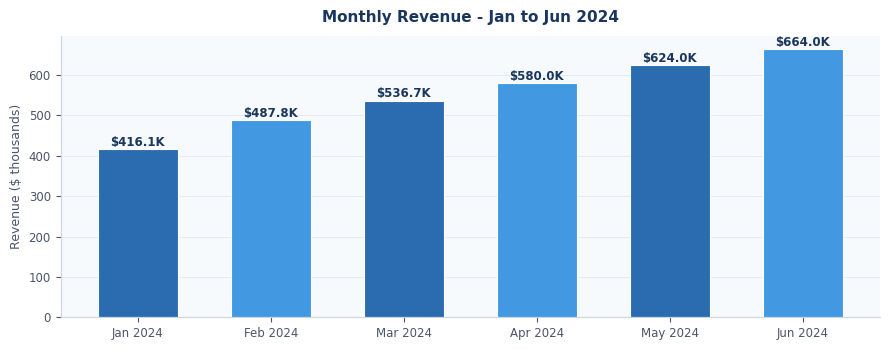

[GENERATE] PDF saved   -> reports\sales_report_2026-03-11.pdf


In [7]:
class SalesPDF(FPDF):
    """Custom FPDF class with branded header and footer."""

    def header(self):
        self.set_fill_color(26, 54, 93)  # navy
        self.rect(0, 0, 210, 20, "F")
        self.set_font("Helvetica", "B", 13)
        self.set_text_color(255, 255, 255)
        self.set_y(4)
        self.cell(0, 12, "Sales Performance Report  |  Jan - Jun 2024", align="C")
        self.set_text_color(0, 0, 0)
        self.ln(14)

    def footer(self):
        self.set_y(-12)
        self.set_font("Helvetica", "", 8)
        self.set_text_color(150, 150, 150)
        self.cell(
            0, 8,
            f"Auto-generated by Sales Report Pipeline  .  {DATE_STAMP}  .  Page {self.page_no()}",
            align="C"
        )


def generate_pdf(summary: pd.DataFrame, monthly: pd.DataFrame) -> str:
    """Build a formatted PDF report with KPI boxes, tables, and bar chart."""
    path       = os.path.join(REPORTS_DIR, f"sales_report_{DATE_STAMP}.pdf")
    chart_path = os.path.join(REPORTS_DIR, "_chart_tmp.png")
    _make_bar_chart(monthly, chart_path)

    pdf = SalesPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    total_rev   = summary["Total_Revenue"].sum()
    total_units = summary["Total_Units"].sum()

    # ── KPI boxes ────────────────────────────────────────────────────
    kpi_data = [
        ("Total Revenue",  f"${total_rev:,.0f}"),
        ("Units Sold",     f"{total_units:,.0f}"),
        ("Products",       str(len(summary))),
        ("Months Tracked", str(len(monthly))),
    ]
    box_w, box_h, x0 = 44, 16, 11
    for i, (lbl, val) in enumerate(kpi_data):
        bx = x0 + i * (box_w + 2)
        pdf.set_fill_color(235, 244, 255)
        pdf.set_draw_color(190, 227, 248)
        pdf.rect(bx, pdf.get_y(), box_w, box_h, "FD")
        pdf.set_xy(bx, pdf.get_y() + 2)
        pdf.set_font("Helvetica", "B", 11)
        pdf.set_text_color(43, 108, 176)
        pdf.cell(box_w, 6, val, align="C")
        pdf.set_xy(bx, pdf.get_y() + 5)
        pdf.set_font("Helvetica", "", 7.5)
        pdf.set_text_color(113, 128, 150)
        pdf.cell(box_w, 5, lbl.upper(), align="C")
    pdf.ln(22)
    pdf.set_text_color(0, 0, 0)

    # ── Product summary table ─────────────────────────────────────────
    NAVY_C  = (26, 54, 93);  WHITE_C  = (255, 255, 255)
    ALT_C   = (235, 244, 255); YELLOW_C = (254, 243, 199)

    pdf.set_font("Helvetica", "B", 11)
    pdf.set_text_color(26, 54, 93)
    pdf.cell(6, 8, "", ln=0)
    pdf.set_fill_color(43, 108, 176)
    pdf.set_draw_color(43, 108, 176)
    pdf.rect(pdf.get_x(), pdf.get_y(), 4, 7, "F")
    pdf.set_x(pdf.get_x() + 5)
    pdf.cell(0, 7, "Product Performance Summary", ln=True)
    pdf.ln(2)

    col_w   = [60, 28, 34, 34, 28]
    headers = ["Product", "Units Sold", "Revenue ($)", "Avg Price ($)", "Rev Share"]

    pdf.set_fill_color(*NAVY_C); pdf.set_text_color(*WHITE_C)
    pdf.set_font("Helvetica", "B", 9); pdf.set_draw_color(255, 255, 255)
    for w, h in zip(col_w, headers):
        pdf.cell(w, 8, h, border=1, align="C", fill=True)
    pdf.ln()

    pdf.set_font("Helvetica", "", 9)
    for i, row in enumerate(summary.itertuples(index=False)):
        fill_c = ALT_C if i % 2 == 0 else WHITE_C
        pdf.set_fill_color(*fill_c); pdf.set_text_color(45, 55, 72)
        pdf.set_draw_color(226, 232, 240)
        values = [
            row.Product, f"{row.Total_Units:,.0f}",
            f"${row.Total_Revenue:,.2f}", f"${row.Avg_Price:,.2f}",
            f"{row.Revenue_Share_Pct:.1f}%",
        ]
        for w, v, a in zip(col_w, values, ["L", "C", "C", "C", "C"]):
            pdf.cell(w, 7, v, border=1, align=a, fill=True)
        pdf.ln()

    pdf.set_fill_color(*YELLOW_C); pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", "B", 9); pdf.set_draw_color(246, 173, 85)
    for w, v in zip(col_w, ["TOTAL", f"{total_units:,.0f}", f"${total_rev:,.2f}", "-", "100.0%"]):
        pdf.cell(w, 8, v, border=1, align="C", fill=True)
    pdf.ln(10)

    # ── Monthly Revenue bar chart ─────────────────────────────────────
    pdf.set_font("Helvetica", "B", 11)
    pdf.set_text_color(26, 54, 93)
    pdf.set_fill_color(43, 108, 176)
    cur_x = pdf.get_x() + 6
    pdf.rect(cur_x, pdf.get_y(), 4, 7, "F")
    pdf.set_x(cur_x + 5)
    pdf.cell(0, 7, "Monthly Revenue - Bar Chart", ln=True)
    pdf.ln(2)
    pdf.image(chart_path, x=11, w=185)
    pdf.ln(4)

    # ── Monthly revenue table ─────────────────────────────────────────
    pdf.set_font("Helvetica", "B", 11)
    pdf.set_text_color(26, 54, 93)
    pdf.rect(pdf.get_x() + 6, pdf.get_y(), 4, 7, "F")
    pdf.set_x(pdf.get_x() + 11)
    pdf.cell(0, 7, "Monthly Revenue Breakdown", ln=True)
    pdf.ln(2)

    m_col_w  = [50, 50, 50]
    m_headers = ["Month", "Revenue ($)", "% of Total"]
    pdf.set_fill_color(*NAVY_C); pdf.set_text_color(*WHITE_C)
    pdf.set_font("Helvetica", "B", 9); pdf.set_draw_color(255, 255, 255)
    pdf.set_x(11)
    for w, h in zip(m_col_w, m_headers):
        pdf.cell(w, 8, h, border=1, align="C", fill=True)
    pdf.ln()

    pdf.set_font("Helvetica", "", 9)
    for i, row in enumerate(monthly.itertuples(index=False)):
        fill_c = ALT_C if i % 2 == 0 else WHITE_C
        pdf.set_fill_color(*fill_c); pdf.set_text_color(45, 55, 72)
        pdf.set_draw_color(226, 232, 240)
        pct  = row.Monthly_Revenue / total_rev * 100
        vals = [row.Month, f"${row.Monthly_Revenue:,.2f}", f"{pct:.1f}%"]
        pdf.set_x(11)
        for w, v in zip(m_col_w, vals):
            pdf.cell(w, 7, v, border=1, align="C", fill=True)
        pdf.ln()

    pdf.set_fill_color(*YELLOW_C); pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", "B", 9); pdf.set_draw_color(246, 173, 85)
    pdf.set_x(11)
    for w, v in zip(m_col_w, ["TOTAL", f"${total_rev:,.2f}", "100.0%"]):
        pdf.cell(w, 8, v, border=1, align="C", fill=True)
    pdf.ln()

    pdf.output(path)
    os.remove(chart_path)
    print(f"[GENERATE] PDF saved   -> {path}")
    return path


pdf_path = generate_pdf(summary, monthly)

---
## Step 4 — DELIVER (Email)

Sends the chosen report as an email attachment via **SMTP with STARTTLS** encryption.

> ⚠️ **Security note:** Never hard-code credentials. Use environment variables or a secrets manager in production:
> ```bash
> export REPORT_SENDER=you@gmail.com
> export REPORT_PASSWORD=your_app_password
> export REPORT_RECIPIENT=manager@company.com
> ```
> For Gmail, generate an **App Password** at https://myaccount.google.com/apppasswords

In [8]:
def deliver_email(
    attachment_path: str,
    recipient: str,
    sender: str,
    password: str,
    smtp_host: str = "smtp.gmail.com",
    smtp_port: int = 587,
) -> bool:
    """
    Send a report file as an email attachment via SMTP/STARTTLS.

    Args:
        attachment_path: Path to the file to attach
        recipient:       Recipient email address
        sender:          Sender email address
        password:        Sender app password (use env var in production)
        smtp_host:       SMTP server hostname (default: Gmail)
        smtp_port:       SMTP port (default: 587 for STARTTLS)

    Returns:
        True if sent successfully, False otherwise
    """
    if not all([recipient, sender, password]):
        print("[DELIVER] Email credentials not provided - skipping delivery.")
        return False

    msg             = MIMEMultipart()
    msg["From"]    = sender
    msg["To"]      = recipient
    msg["Subject"] = f"Sales Report - {DATE_STAMP}"

    body = (
        f"Hi,\n\n"
        f"Please find the automated Sales Performance Report for {DATE_STAMP} attached.\n\n"
        f"This report covers Jan - Jun 2024 across all regions and products.\n\n"
        f"Regards,\nAutomated Report Pipeline"
    )
    msg.attach(MIMEText(body, "plain"))

    filename = os.path.basename(attachment_path)
    with open(attachment_path, "rb") as f:
        part = MIMEBase("application", "octet-stream")
        part.set_payload(f.read())
    encoders.encode_base64(part)
    part.add_header("Content-Disposition", f'attachment; filename="{filename}"')
    msg.attach(part)

    try:
        with smtplib.SMTP(smtp_host, smtp_port) as server:
            server.ehlo()
            server.starttls()
            server.login(sender, password)
            server.sendmail(sender, recipient, msg.as_string())
        print(f"[DELIVER] Email sent successfully -> {recipient}")
        return True
    except Exception as e:
        print(f"[DELIVER] Email failed: {e}")
        return False


# Deliver via email (reads credentials from environment variables)
deliver_email(
    attachment_path=pdf_path,
    recipient=os.environ.get("REPORT_RECIPIENT", ""),
    sender=os.environ.get("REPORT_SENDER", ""),
    password=os.environ.get("REPORT_PASSWORD", ""),
)

[DELIVER] Email credentials not provided - skipping delivery.


False

---
## Run the Full Pipeline

This cell runs all four stages in sequence as a single orchestrated pipeline call.

  AUTOMATED SALES REPORT PIPELINE
[EXTRACT] Loaded 30 records across 6 months.
[TRANSFORM] Total revenue: $3,308,612.05
[TRANSFORM] Products: ['Laptop Pro 15', 'Tablet Air 10', 'Smart Watch Ultra', 'Wireless Headphones', 'Bluetooth Speaker']
[GENERATE] Excel saved -> reports\sales_report_2026-03-11.xlsx
[GENERATE] HTML saved  -> reports\sales_report_2026-03-11.html


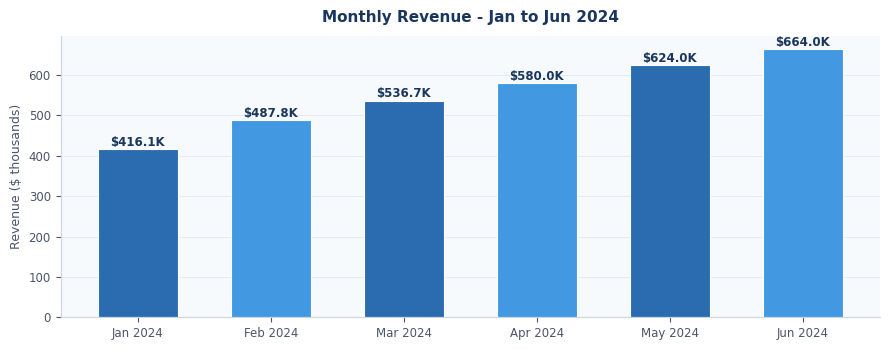

[GENERATE] PDF saved   -> reports\sales_report_2026-03-11.pdf
[DELIVER] Email credentials not provided - skipping delivery.
-------------------------------------------------------
  PIPELINE COMPLETE
  Reports saved in: ./reports/
-------------------------------------------------------

Generated files:
  reports\sales_report_2026-03-11.xlsx  (8.2 KB)
  reports\sales_report_2026-03-11.html  (5.6 KB)
  reports\sales_report_2026-03-11.pdf  (43.9 KB)


In [9]:
def run_pipeline(
    email_recipient: str = "",
    email_sender:    str = "",
    email_password:  str = "",
):
    """Orchestrate the full Extract -> Transform -> Generate -> Deliver pipeline."""
    print("=" * 55)
    print("  AUTOMATED SALES REPORT PIPELINE")
    print("=" * 55)

    raw        = extract_data()
    df, summary, monthly = transform_data(raw)

    excel = generate_excel(df, summary, monthly)
    html  = generate_html(summary, monthly)
    pdf   = generate_pdf(summary, monthly)

    deliver_email(pdf, email_recipient, email_sender, email_password)

    print("-" * 55)
    print("  PIPELINE COMPLETE")
    print(f"  Reports saved in: ./{REPORTS_DIR}/")
    print("-" * 55)
    return excel, html, pdf


# Run the full pipeline
excel_path, html_path, pdf_path = run_pipeline(
    email_recipient=os.environ.get("REPORT_RECIPIENT", ""),
    email_sender=os.environ.get("REPORT_SENDER",    ""),
    email_password=os.environ.get("REPORT_PASSWORD", ""),
)

print(f"\nGenerated files:")
for path in [excel_path, html_path, pdf_path]:
    size = os.path.getsize(path) / 1024
    print(f"  {path}  ({size:.1f} KB)")